# Assignment 3 – Parte 2: Mapas con Geopandas y Folium

**Pregunta del grupo:** ¿el Estado declara emergencia donde más llueve?

**Datos:** `datos/dataset.csv` (Parte 1, sin cambios): 25 departamentos, lluvia acumulada en la capital del 1 de enero al 31 de mayo de 2022 y declaratorias de emergencia por lluvias de la PCM.

**Geometrías:** `datos/peru_departamental.geojson`, copia del archivo que el grupo descargó en el Assignment 2 de [juaneladio/peru-geojson](https://github.com/juaneladio/peru-geojson). Su código de departamento es la columna `FIRST_IDDP`, texto de 2 dígitos.

**Aviso:** la lluvia es la de **una sola ciudad (la capital)** por departamento, así que cada departamento se pinta con un único valor. El mapa no muestra cuánto llovió en todo el territorio.

In [1]:
from pathlib import Path

import folium
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATOS = Path("datos")

## 1. Cargar la tabla y las geometrías

La tabla se lee con `dtype={"ubigeo": str}` para conservar el cero a la izquierda (`'01'` y no `1`) y con `encoding="utf-8-sig"` por la marca BOM del archivo. En el geojson, el código `FIRST_IDDP` se renombra a `ubigeo` y también se lee como texto.

In [2]:
df = pd.read_csv(DATOS / "dataset.csv", dtype={"ubigeo": str}, encoding="utf-8-sig")
geo = gpd.read_file(DATOS / "peru_departamental.geojson")
geo = geo.rename(columns={"FIRST_IDDP": "ubigeo", "NOMBDEP": "nombre_mapa"})[["ubigeo", "nombre_mapa", "geometry"]]

print("Tabla     :", df.shape, "| ubigeo:", df["ubigeo"].dtype, "| ejemplo:", repr(df.loc[0, "ubigeo"]))
print("Geometrías:", geo.shape, "| ubigeo:", geo["ubigeo"].dtype, "| ejemplo:", repr(geo.loc[0, "ubigeo"]))
print("CRS:", geo.crs)

Tabla     : (25, 7) | ubigeo: object | ejemplo: '01'
Geometrías: (25, 3) | ubigeo: object | ejemplo: '01'
CRS: EPSG:4326


## 2. Cruce por ubigeo y control de lo que no cruzó

Antes del `merge` se comparan los dos conjuntos de códigos. El cruce se hace con `how="left"` **desde el mapa** (así no se pierde ningún departamento) y con `validate="one_to_one"`; luego se cuentan los registros de cada lado que no encontraron pareja.

In [3]:
ub_tabla, ub_mapa = set(df["ubigeo"]), set(geo["ubigeo"])
print("Ubigeos que coinciden:", len(ub_tabla & ub_mapa), "de", len(ub_tabla))

mapa = geo.merge(df, on="ubigeo", how="left", validate="one_to_one", indicator=True)

sin_tabla = (mapa["_merge"] != "both").sum()                      # polígonos sin fila en la tabla
sin_mapa = len(ub_tabla - ub_mapa)                                # filas de la tabla sin polígono
print("Registros de la tabla que NO cruzaron con el mapa:", sin_mapa, "de", len(df))
print("Polígonos del mapa que NO cruzaron con la tabla  :", sin_tabla, "de", len(geo))

# Los nombres de los dos lados deben ser el mismo departamento (sin tildes y en mayúsculas en el mapa)
quitar_tildes = lambda s: s.str.normalize("NFKD").str.encode("ascii", "ignore").str.decode("ascii").str.upper()
distintos = mapa[quitar_tildes(mapa["departamento"]) != mapa["nombre_mapa"]]
print("Nombres que no coinciden entre tabla y mapa:", len(distintos))

# Totales: el cruce no debe perder ni inventar nada
assert sin_mapa == 0 and sin_tabla == 0 and len(distintos) == 0
assert mapa["lluvia_total_mm"].sum() == df["lluvia_total_mm"].sum()
assert mapa["declaratorias"].sum() == df["declaratorias"].sum()
print("Lluvia total (mm) tabla = mapa:", round(df["lluvia_total_mm"].sum(), 1), "| declaratorias tabla = mapa:", df["declaratorias"].sum())
mapa = mapa.drop(columns="_merge")
mapa["declaratoria"] = mapa["declaratorias"].gt(0).map({True: "Con declaratoria", False: "Sin declaratoria"})

Ubigeos que coinciden: 25 de 25
Registros de la tabla que NO cruzaron con el mapa: 0 de 25
Polígonos del mapa que NO cruzaron con la tabla  : 0 de 25
Nombres que no coinciden entre tabla y mapa: 0
Lluvia total (mm) tabla = mapa: 13290.2 | declaratorias tabla = mapa: 3


## 3. Mapas estáticos con Geopandas (coropletas por cuantiles)

`scheme="quantiles"` reparte los departamentos en grupos del mismo tamaño, así un valor extremo como Loreto no deja el resto del mapa del mismo color. Se dibujan los 3 departamentos con declaratoria con un borde rojo grueso para poder compararlos con la lluvia.

In [4]:
FUENTE = "Fuente: Open-Meteo (capital de cada departamento) y gob.pe (PCM), 1 ene – 31 may 2022. Elaboración propia."
con_decl = mapa[mapa["declaratorias"] > 0]


def mapa_estatico(columna, titulo, subtitulo, cmap, k, leyenda):
    fig, ax = plt.subplots(figsize=(7, 9))
    mapa.plot(column=columna, cmap=cmap, scheme="quantiles", k=k, legend=True,
              edgecolor="white", linewidth=0.6, ax=ax,
              legend_kwds={"loc": "lower left", "fontsize": 9, "title": leyenda, "title_fontsize": 9, "fmt": "{:.0f}"})
    con_decl.boundary.plot(ax=ax, color="#c0392b", linewidth=2.2)
    ax.set_axis_off()
    ax.set_title(f"{titulo}\n", fontsize=13, fontweight="bold", loc="left")
    ax.text(0, 1.0, subtitulo, transform=ax.transAxes, fontsize=9.5, va="bottom")
    fig.text(0.02, 0.01, FUENTE, fontsize=8, color="gray")
    return fig, ax

Cortes de lluvia (mm), quintiles: [79.0, 395.0, 736.0, 825.0]


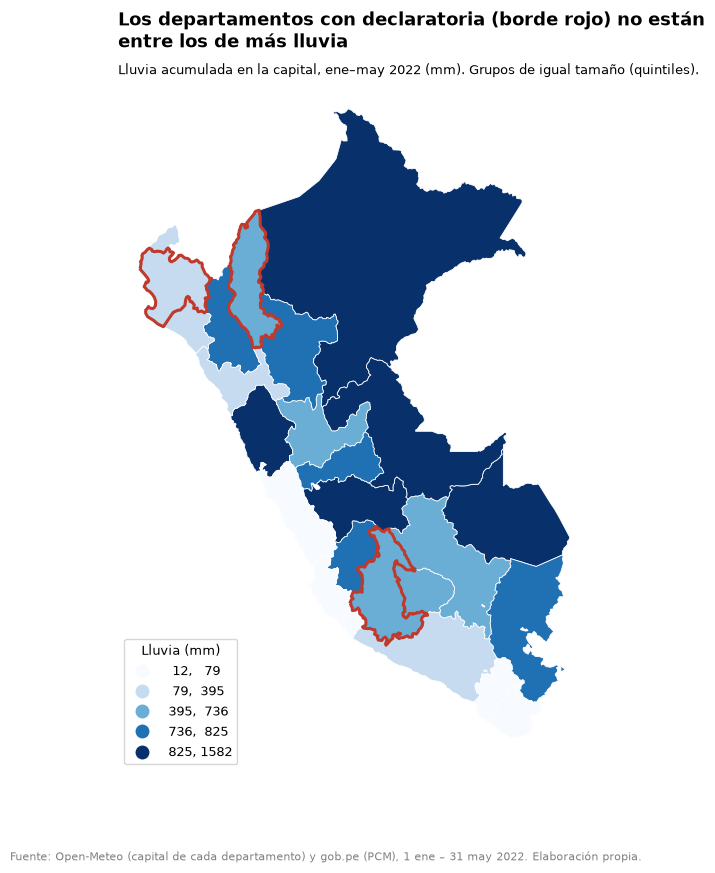

In [5]:
# Mapa 1: lluvia acumulada
q_lluvia = mapa["lluvia_total_mm"].quantile([0.2, 0.4, 0.6, 0.8]).round(0).tolist()
print("Cortes de lluvia (mm), quintiles:", q_lluvia)

fig1, ax1 = mapa_estatico(
    "lluvia_total_mm",
    "Los departamentos con declaratoria (borde rojo) no están\nentre los de más lluvia",
    "Lluvia acumulada en la capital, ene–may 2022 (mm). Grupos de igual tamaño (quintiles).",
    "Blues", 5, "Lluvia (mm)",
)
plt.show()

Departamentos con 0 días de lluvia fuerte: 10 de 25
Cortes (cuartiles): [0.0, 1.0, 3.0]


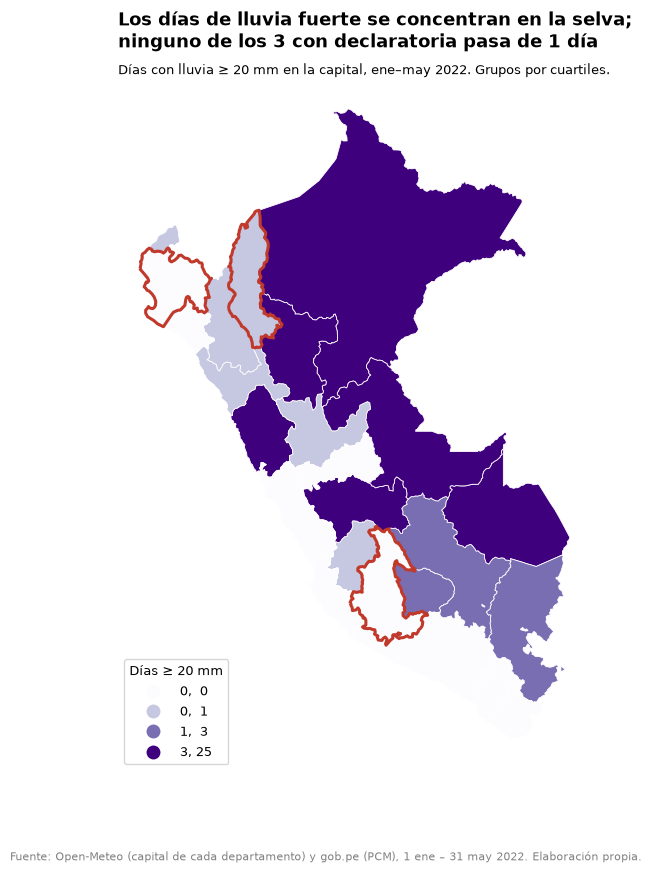

In [6]:
# Mapa 2: días con lluvia fuerte (>= 20 mm)
print("Departamentos con 0 días de lluvia fuerte:", (mapa["dias_lluvia_fuerte"] == 0).sum(), "de", len(mapa))
print("Cortes (cuartiles):", mapa["dias_lluvia_fuerte"].quantile([0.25, 0.5, 0.75]).tolist())

fig2, ax2 = mapa_estatico(
    "dias_lluvia_fuerte",
    "Los días de lluvia fuerte se concentran en la selva;\nninguno de los 3 con declaratoria pasa de 1 día",
    "Días con lluvia ≥ 20 mm en la capital, ene–may 2022. Grupos por cuartiles.",
    "Purples", 4, "Días ≥ 20 mm",
)
plt.show()

**Nota sobre este segundo mapa:** 10 de los 25 departamentos (40 %) tienen 0 días de lluvia fuerte, así que los cuartiles se amontonan en valores muy bajos: la primera clase es solo "0 días" y la segunda va de 0 a 1 día. Es una limitación de la variable (muchos ceros y pocos valores distintos), no un error del mapa.

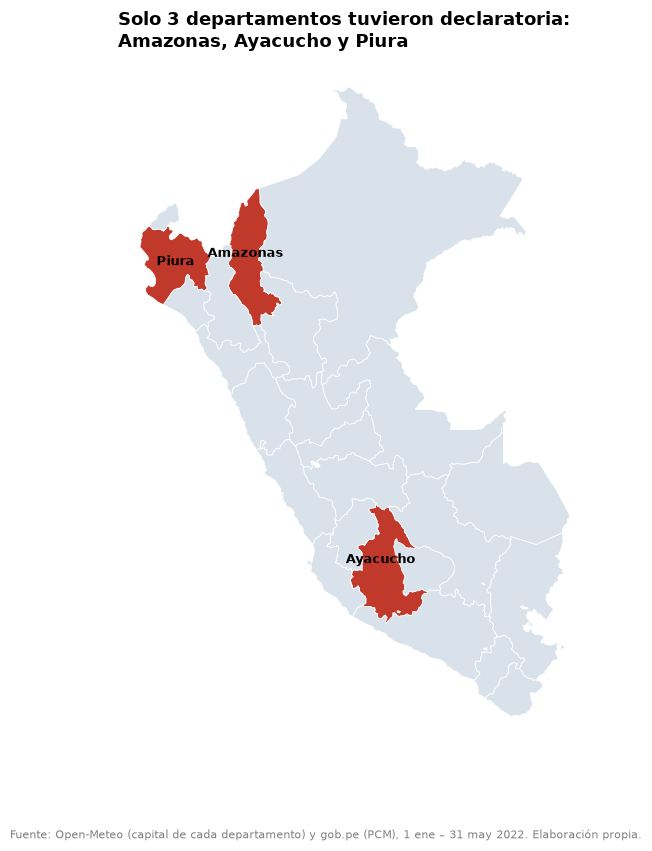

In [7]:
# Mapa 3: declaratorias (categorías, porque solo 3 departamentos tienen alguna y los cuantiles no sirven)
fig3, ax3 = plt.subplots(figsize=(7, 9))
mapa.plot(ax=ax3,
          color=mapa["declaratoria"].map({"Con declaratoria": "#c0392b", "Sin declaratoria": "#d9e2ea"}),
          edgecolor="white", linewidth=0.6)
for fila in con_decl.itertuples():
    p = fila.geometry.representative_point()
    ax3.annotate(fila.departamento, (p.x, p.y), ha="center", fontsize=9, fontweight="bold")
ax3.set_axis_off()
ax3.set_title("Solo 3 departamentos tuvieron declaratoria:\nAmazonas, Ayacucho y Piura", fontsize=13, fontweight="bold", loc="left")
fig3.text(0.02, 0.01, FUENTE, fontsize=8, color="gray")
plt.show()

## 4. Mapa interactivo con Folium

`Choropleth` pinta la lluvia acumulada con los mismos cortes por cuantiles, y una capa `GeoJson` encima, transparente, agrega el **tooltip** (un `Choropleth` solo pinta). Al pasar el mouse sale el departamento, su lluvia, los días de lluvia fuerte, las declaratorias y las prórrogas. Los tres departamentos con declaratoria llevan además un contorno rojo.

El mapa pesa cientos de KB; por eso, **al guardar el notebook se borró la salida de la celda de abajo**. Se vuelve a ver ejecutándola.

In [8]:
bins = [0] + mapa["lluvia_total_mm"].quantile([0.2, 0.4, 0.6, 0.8, 1.0]).round(1).tolist()
bins[-1] = float(np.ceil(mapa["lluvia_total_mm"].max()))      # que el máximo quede dentro del último grupo
print("Cortes del Choropleth (mm):", bins)

m = folium.Map(location=[-9.2, -75.0], zoom_start=5, tiles="cartodbpositron")

folium.Choropleth(
    geo_data=mapa, data=mapa,
    columns=["ubigeo", "lluvia_total_mm"],
    key_on="feature.properties.ubigeo",
    fill_color="Blues", fill_opacity=0.8, line_opacity=0.5,
    legend_name="Lluvia acumulada en la capital, ene–may 2022 (mm)",
    bins=bins,
).add_to(m)

folium.GeoJson(
    mapa[mapa["declaratorias"] > 0],
    style_function=lambda x: {"fillOpacity": 0, "color": "#c0392b", "weight": 3},
    name="Con declaratoria",
).add_to(m)

folium.GeoJson(
    mapa[["ubigeo", "departamento", "capital", "lluvia_total_mm", "dias_lluvia_fuerte",
          "declaratorias", "prorrogas", "geometry"]],
    style_function=lambda x: {"fillOpacity": 0, "weight": 0},
    tooltip=folium.GeoJsonTooltip(
        fields=["departamento", "capital", "lluvia_total_mm", "dias_lluvia_fuerte", "declaratorias", "prorrogas"],
        aliases=["Departamento:", "Capital:", "Lluvia (mm):", "Días ≥ 20 mm:", "Declaratorias:", "Prórrogas:"],
        sticky=True,
    ),
).add_to(m)

m

In [9]:
# Comprobación de los números que se citan en los textos de abajo
orden = mapa.sort_values("lluvia_total_mm", ascending=False)
print("Los 5 con más lluvia:", ", ".join(f"{r.departamento} ({r.lluvia_total_mm})" for r in orden.head(5).itertuples()))
print("Los 5 con menos lluvia:", ", ".join(f"{r.departamento} ({r.lluvia_total_mm})" for r in orden.tail(5).itertuples()))
puestos = orden.reset_index(drop=True)
puestos = {r.departamento: i + 1 for i, r in puestos.iterrows()}
print("Puesto en lluvia de los 3 con declaratoria:", {d: puestos[d] for d in con_decl["departamento"]})
print("Su lluvia (mm):", con_decl.set_index("departamento")["lluvia_total_mm"].to_dict())
print("Su días ≥ 20 mm:", con_decl.set_index("departamento")["dias_lluvia_fuerte"].to_dict())
print("Mediana de lluvia de los 25:", mapa["lluvia_total_mm"].median())

assert list(orden.head(5)["departamento"]) == ["Loreto", "Ucayali", "Áncash", "Junín", "Madre de Dios"]
assert set(orden.tail(5)["departamento"]) == {"Lima", "Tacna", "Moquegua", "Ica", "Callao"}
assert set(con_decl["departamento"]) == {"Amazonas", "Ayacucho", "Piura"}
assert (con_decl["lluvia_total_mm"] <= mapa["lluvia_total_mm"].median()).all()
assert (con_decl["dias_lluvia_fuerte"] <= 1).all()

Los 5 con más lluvia: Loreto (1581.8), Ucayali (1288.8), Áncash (975.3), Junín (910.4), Madre de Dios (908.0)
Los 5 con menos lluvia: Callao (39.2), Ica (25.1), Moquegua (17.8), Lima (13.9), Tacna (11.5)
Puesto en lluvia de los 3 con declaratoria: {'Amazonas': 15, 'Ayacucho': 13, 'Piura': 20}
Su lluvia (mm): {'Amazonas': 436.5, 'Ayacucho': 485.1, 'Piura': 89.2}
Su días ≥ 20 mm: {'Amazonas': 1, 'Ayacucho': 0, 'Piura': 0}
Mediana de lluvia de los 25: 485.1


## 5. Qué patrón geográfico se ve

**Se ve un gradiente de oeste a este.** La lluvia aumenta desde la costa hacia la selva:
- **Costa seca:** Tacna (11.5 mm), Lima (13.9 mm), Moquegua (17.8 mm), Ica (25.1 mm) y Callao (39.2 mm) son los 5 con menos lluvia, y la costa norte (Piura, Lambayeque, La Libertad: unos 90–100 mm) se pinta en los dos tonos más claros.
- **Selva y parte de la sierra, más lluvia:** Loreto (1,581.8 mm), Ucayali (1,288.8 mm), Áncash (975.3 mm), Junín (910.4 mm) y Madre de Dios (908.0 mm) son los 5 más lluviosos. Loreto, Ucayali y Madre de Dios forman un solo bloque oscuro en el este y noreste del país. Los días de lluvia fuerte (segundo mapa) siguen casi el mismo reparto: 25 en Loreto, 20 en Ucayali y 13 en Madre de Dios.

**Las declaratorias no siguen ese gradiente.** Son 3 departamentos separados entre sí: Piura (costa norte, 89.2 mm, puesto 20 de 25), Amazonas (436.5 mm, puesto 15) y Ayacucho (485.1 mm, puesto 13). Los tres están en la mediana de lluvia de los 25 departamentos (485.1 mm) o por debajo, y tienen a lo más 1 día de lluvia fuerte. Ninguna declaratoria cae en el bloque oscuro del este.

## 6. ¿El mapa dice algo distinto de los gráficos de la Parte 1?

**Respuesta corta: no, el mapa llega a la misma conclusión que los gráficos de la Parte 1.** En ambos, Loreto, Ucayali y Áncash son los más lluviosos sin declaratoria, y los 3 departamentos con declaratoria quedan por debajo de la mediana de lluvia. Con los datos disponibles la respuesta a la pregunta del grupo sigue siendo la misma: **en esta temporada el Estado no declaró emergencia por lluvias donde más llovió**.

**Lo que el mapa agrega** (los gráficos no lo muestran):
- **Dónde** está lo más lluvioso: un bloque continuo en la selva del este y noreste, y no departamentos sueltos.
- Los 3 departamentos con declaratoria **no forman una zona**: dos están en el norte (Piura y Amazonas, separados por Cajamarca) y uno en el sur-centro (Ayacucho).
- Piura destaca: es costa norte, con poca lluvia en su capital, y aun así tiene declaratoria. Con estos datos no se puede decir por qué; solo que la lluvia acumulada de una ciudad no basta para explicar dónde se declara.

**Cuidados al leer el mapa** (por lo que no debería sobreinterpretarse):
- Cada departamento se pinta con **la lluvia de una sola ciudad, su capital**. Iquitos pinta todo Loreto, que es enorme, y Chachapoyas pinta todo Amazonas.
- El ojo se va a los departamentos **más grandes** (Loreto, Ucayali, Madre de Dios), mientras que Callao o Tumbes casi no se ven aunque cuenten igual en la tabla.
- Se encontró un solo decreto de lluvias en la temporada (DS 032-2022-PCM) que cubre a los 3 departamentos, así que el mapa describe estos datos y no prueba que el Estado nunca declare emergencia donde más llueve.